In [1]:
from pathlib import Path

# Project root - located through the .projectroot marker file, so this
# notebook runs from any checkout location.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / ".projectroot").exists())

import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         10,
    "axes.labelsize":    10,
    "axes.titlesize":    11,
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# Hydrological year axis: Sep 1 (day 0) → Aug 31 (day ~365)
_ref = pd.Timestamp("2001-09-01")
TICK_POS = (pd.to_datetime([
    "2001-09-01","2001-10-01","2001-11-01","2001-12-01",
    "2002-01-01","2002-02-01","2002-03-01","2002-04-01",
    "2002-05-01","2002-06-01","2002-07-01","2002-08-01",
]) - _ref).days.tolist()
TICK_LABS = ["Sep","Oct","Nov","Dec","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug"]


base_dir = ROOT

os.chdir(base_dir)


In [2]:
nc_path = str(ROOT / "calibration/calibration_data/raw_data/mag25/slf_dataset/Mag25_all.nc")
ds = xr.open_dataset(nc_path)

df = ds[["HS", "SWE"]].to_dataframe().reset_index()
for col in ["HS", "SWE"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Bulk density [kg m⁻³] = SWE [mm] / HS [m]
df["bulk_density_kg_m3"] = df["SWE"] / df["HS"].replace(0, np.nan)

# Values > 800 kg m⁻³ are physically impossible for natural snowpacks and
# indicate measurement artefacts (ice layers, sensor drift).
high_rho_mask = df["bulk_density_kg_m3"] > 600
df_clean = df.copy()
df_clean.loc[high_rho_mask, ["HS", "SWE", "bulk_density_kg_m3"]] = np.nan

print(f"Records masked (ρ > 600 kg m⁻³): {high_rho_mask.sum()}")
print(f"Stations: {df['station'].nunique()}  |  Time steps: {df['time'].nunique()}")


print(f"Percentage of records masked: {high_rho_mask.sum() / len(df['SWE'].dropna()) * 100:.4f}%")



Records masked (ρ > 600 kg m⁻³): 10
Stations: 41  |  Time steps: 2191
Percentage of records masked: 0.8643%


In [3]:
def iqr_bounds(s):
    q1, q3 = s.dropna().quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Per-variable QC summary on the raw (unfiltered) data
rows = []
for col in ["HS", "SWE", "bulk_density_kg_m3"]:
    valid = df[col].dropna()
    lo, hi = iqr_bounds(df[col])
    n_out = int(((df[col] < lo) | (df[col] > hi)).fillna(False).sum())
    rows.append({
        "variable":   col,
        "n":          valid.size,
        "min":        round(valid.min(), 3),
        "max":        round(valid.max(), 3),
        "mean":       round(valid.mean(), 3),
        "median":     round(valid.median(), 3),
        "iqr_lo":     round(lo, 3),
        "iqr_hi":     round(hi, 3),
        "n_outliers": n_out,
    })

print("Physical range checks (raw data):")
for col in ["HS", "SWE", "bulk_density_kg_m3"]:
    print(f"  {col} ≤ 0: {int((df[col] <= 0).sum())}")
print()
display(pd.DataFrame(rows))

# Extreme density values — almost certainly measurement artefacts
display(
    df.loc[df["bulk_density_kg_m3"] > 1000, ["station", "time", "bulk_density_kg_m3"]]
    .sort_values("bulk_density_kg_m3")
    .rename(columns={"bulk_density_kg_m3": "ρ [kg m⁻³]"})
)

Physical range checks (raw data):
  HS ≤ 0: 53839
  SWE ≤ 0: 0
  bulk_density_kg_m3 ≤ 0: 0



,variable,n,min,max,mean,median,iqr_lo,iqr_hi,n_outliers
0,HS,89831,0.000,3.13,0.224,0.000,-0.510,0.850,8070
1,SWE,1157,2.000,1389.00,227.687,185.000,-195.000,605.000,46
2,bulk_density_kg_m3,1157,45.455,1680.00,293.841,286.232,45.163,526.748,23


,station,time,ρ [kg m⁻³]
69798,Fionnay,2021-04-30 06:00:00,1680.0


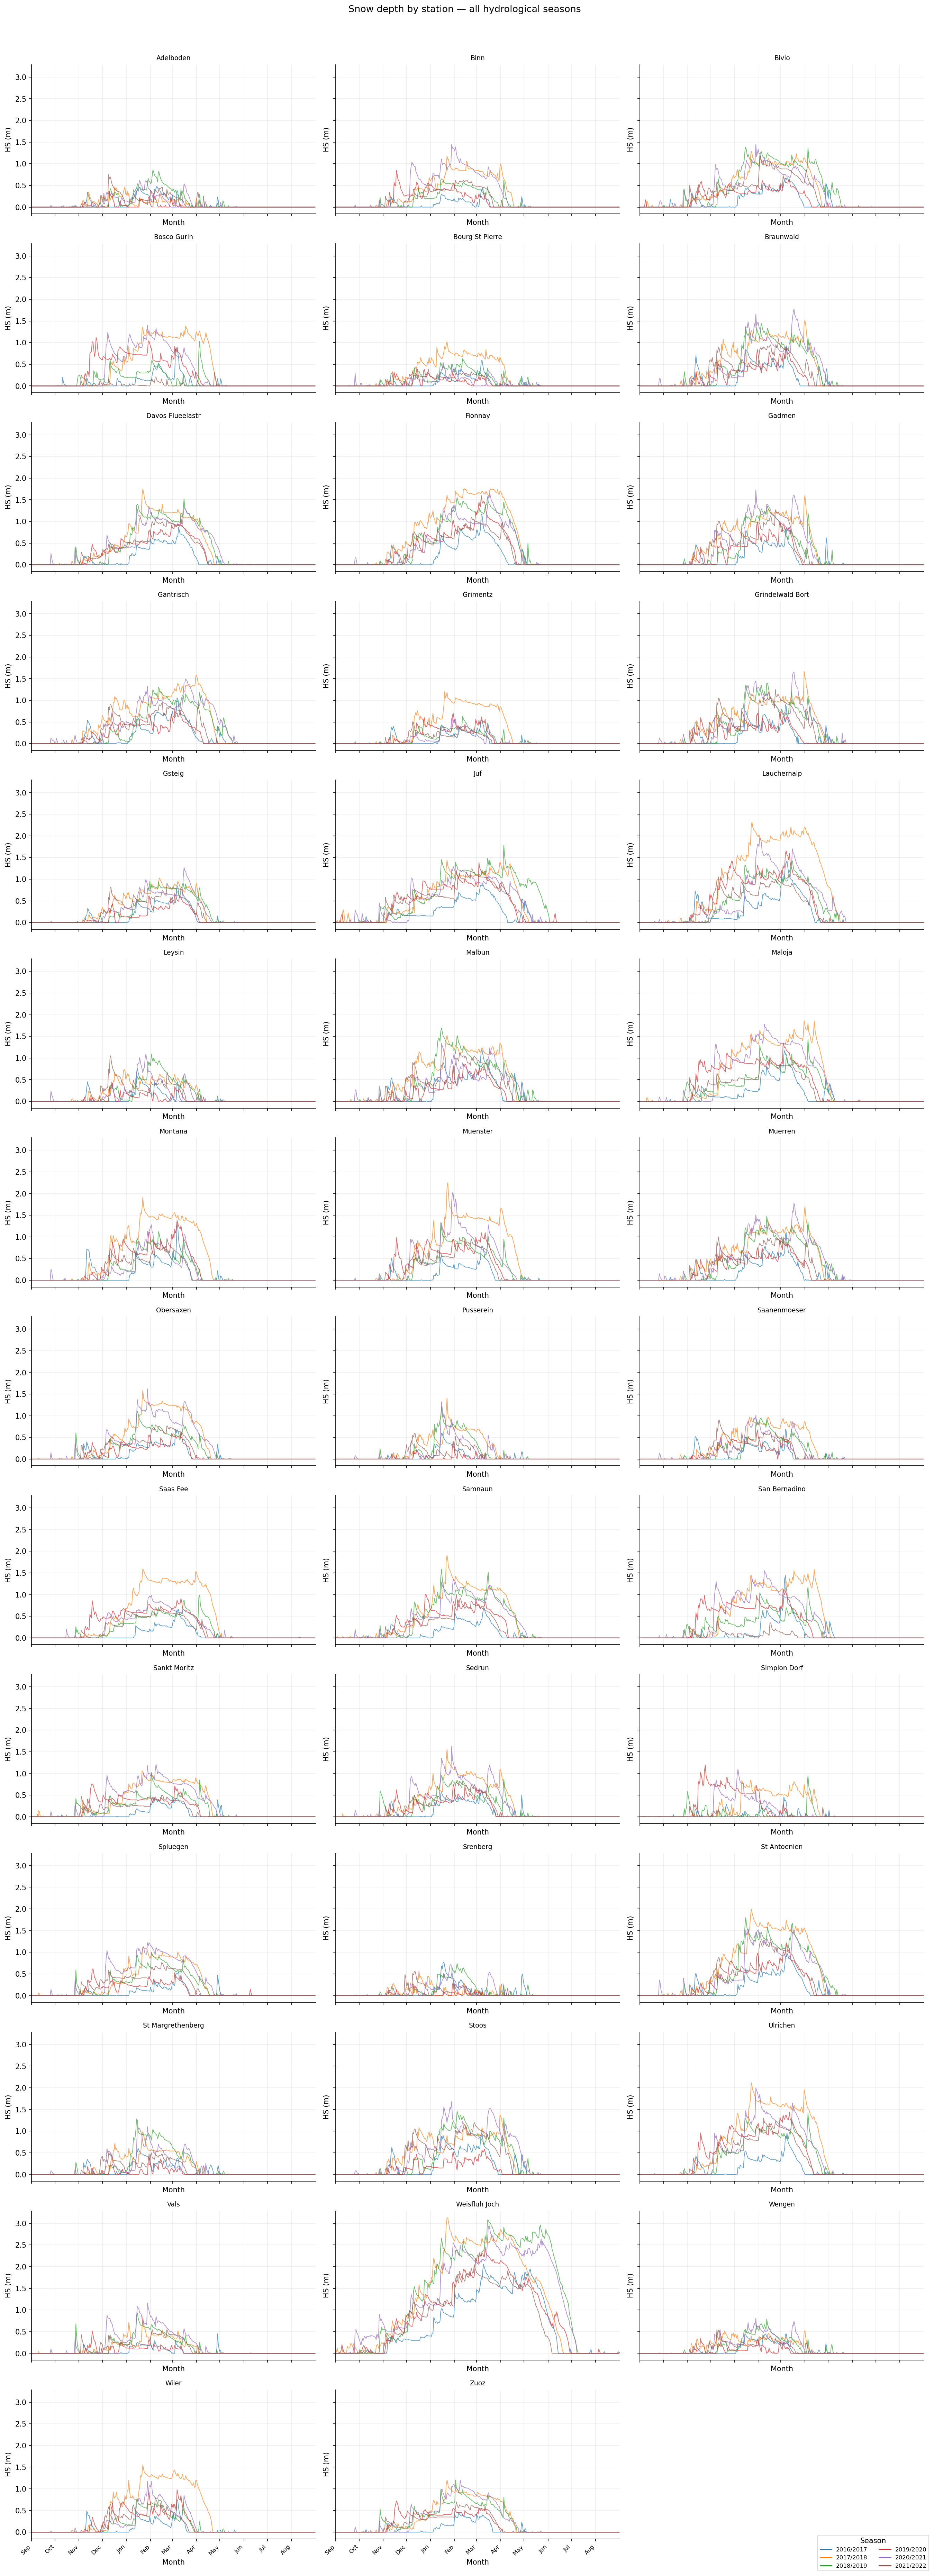

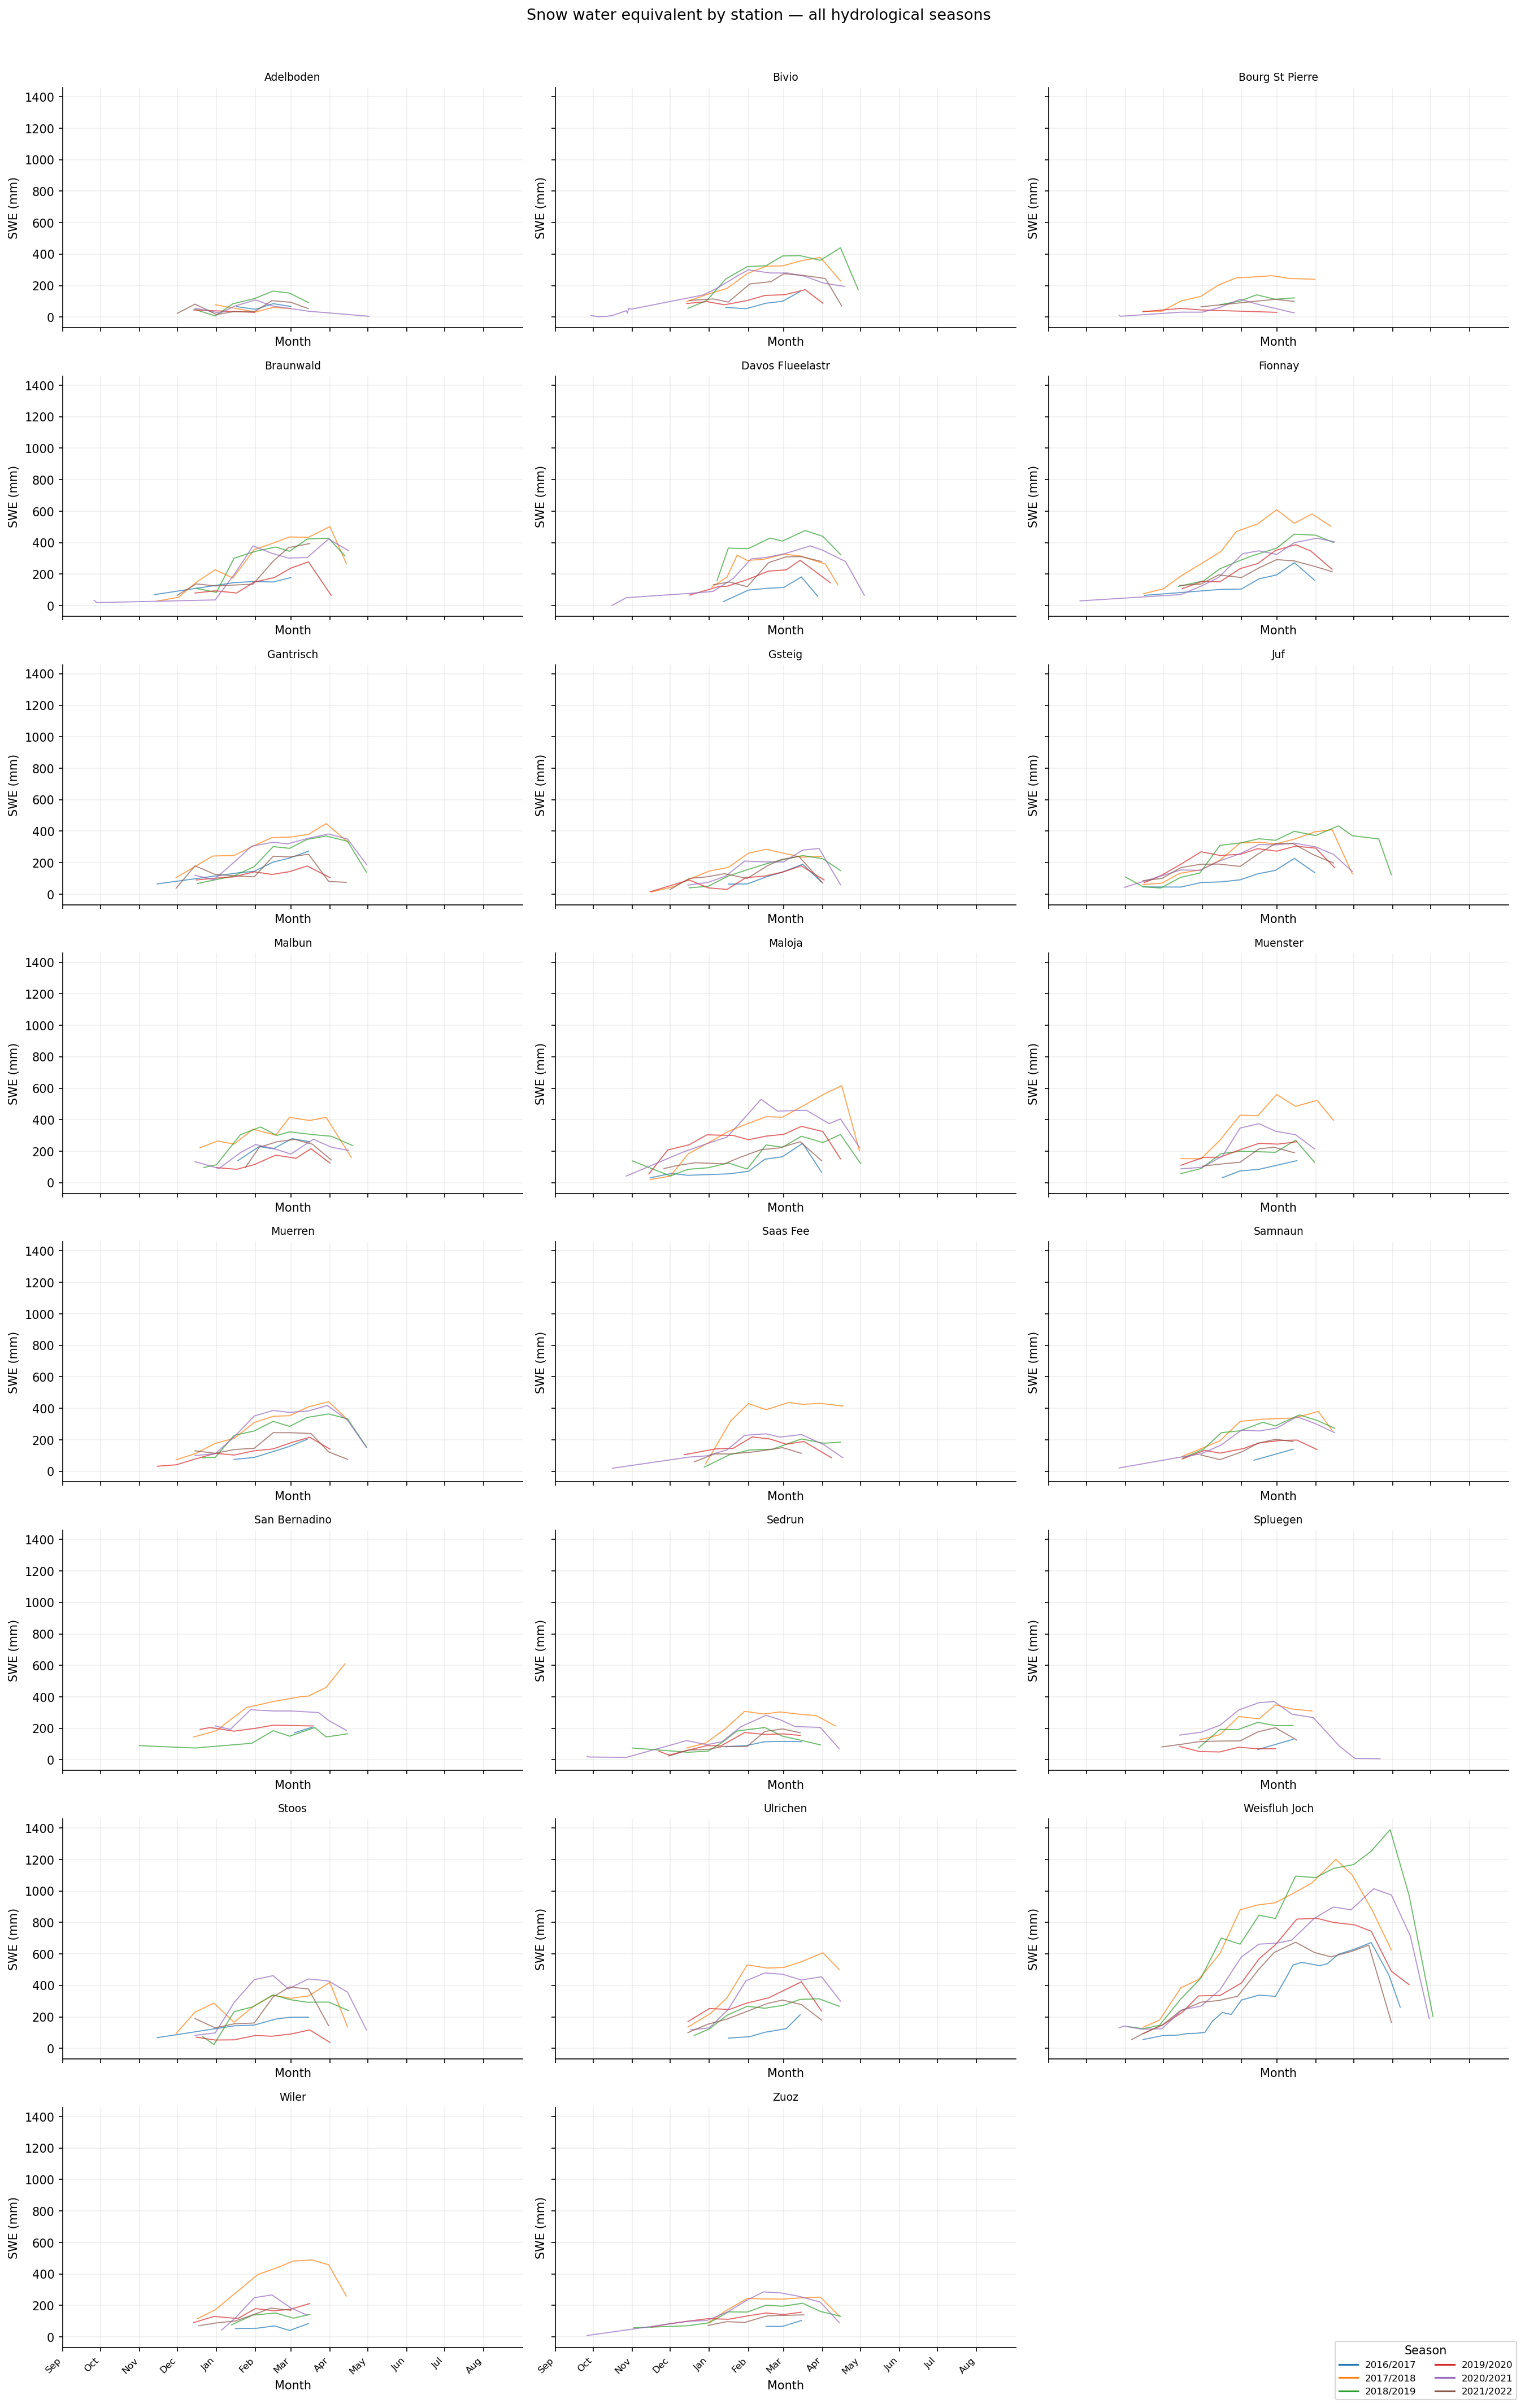

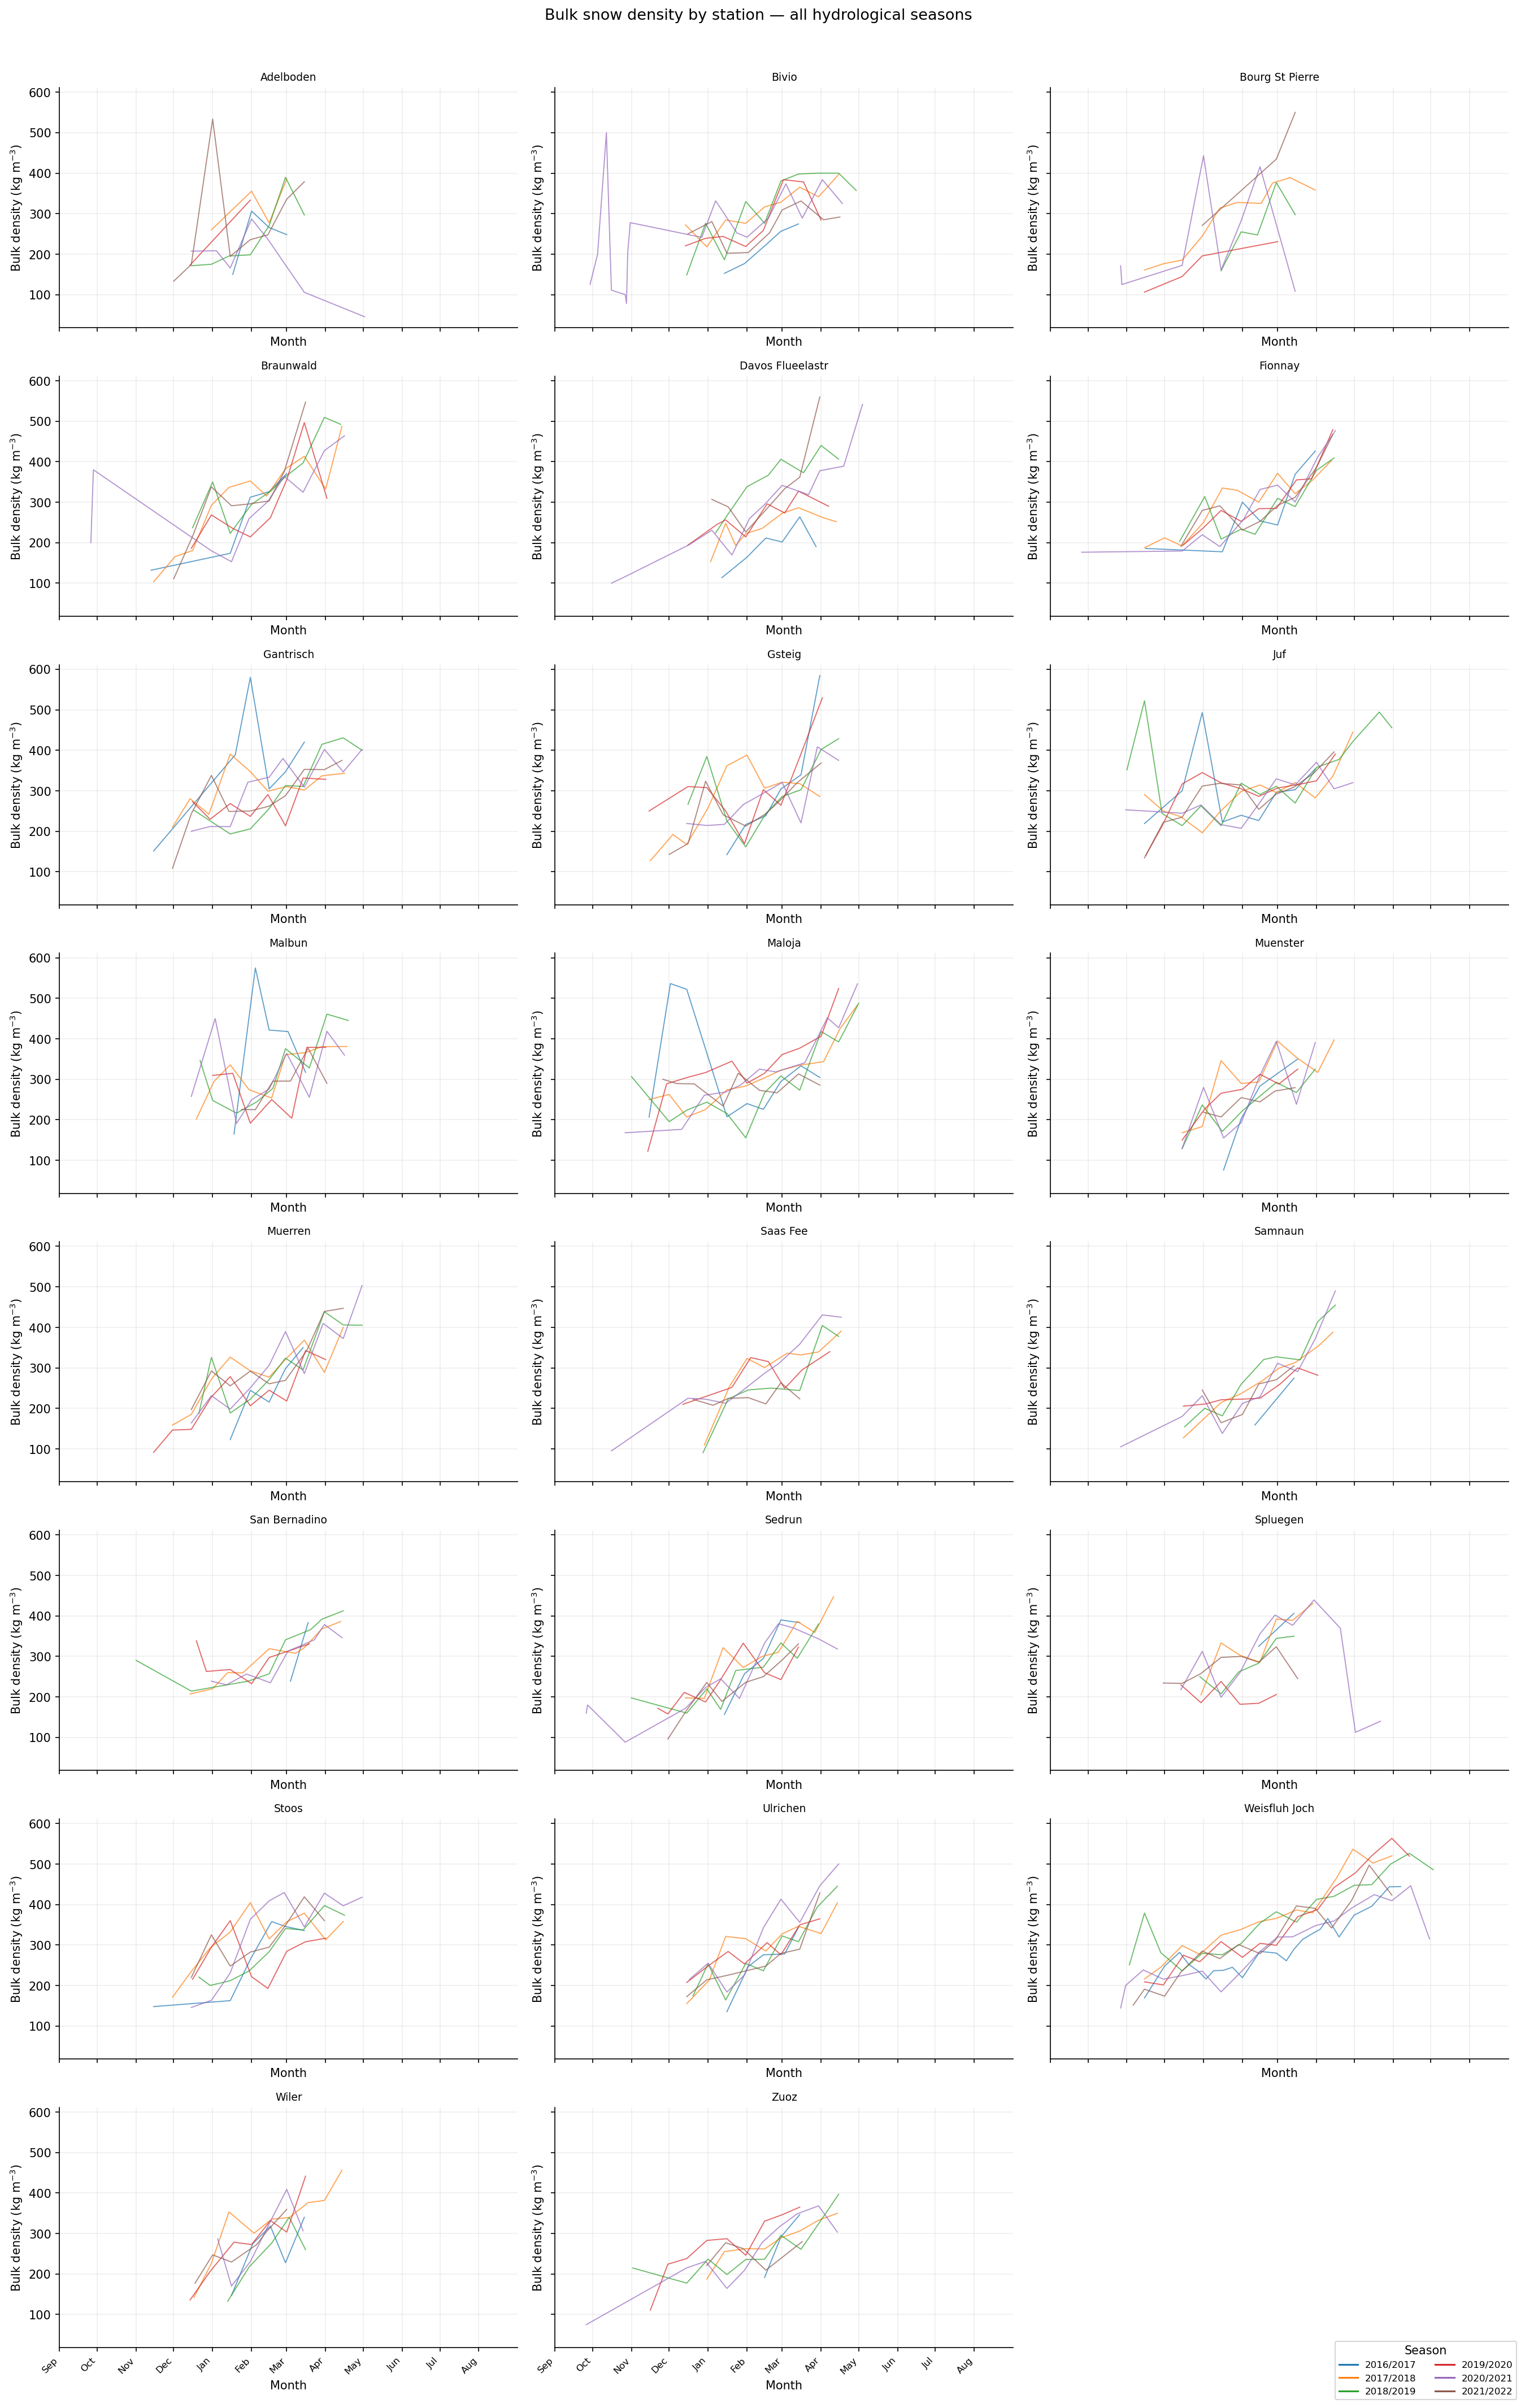

In [4]:
def add_hydro_season(d, value_col):
    """Return copy of d with 'season' label and 'season_day' (Sep 1 = 0) added."""
    d = d[["station", "time", value_col]].dropna(subset=[value_col]).copy()
    yr = np.where(d["time"].dt.month >= 9, d["time"].dt.year, d["time"].dt.year - 1)
    d["season"]     = yr.astype(str) + "/" + (yr + 1).astype(str)
    d["season_day"] = (d["time"] - pd.to_datetime(yr.astype(str) + "-09-01")).dt.days
    return d


def plot_seasonal_by_station(df, value_col, ylabel, title):
    """Small-multiple plot: one panel per station, one trace per season."""
    d        = add_hydro_season(df, value_col)
    stations = sorted(d["station"].unique())
    ncols    = 3
    nrows    = int(np.ceil(len(stations) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    # Assign a consistent colour per season across all panels
    seasons_all  = sorted(d["season"].unique())
    season_color = {s: plt.cm.tab10(i % 10) for i, s in enumerate(seasons_all)}

    for i, station in enumerate(stations):
        ax  = axes[i]
        sdf = d[d["station"] == station].sort_values("time")
        for season, g in sdf.groupby("season"):
            ax.plot(g["season_day"], g[value_col], lw=0.9, alpha=0.7,
                    color=season_color[season])
        ax.set_title(station.replace("_", " "), fontsize=9)
        ax.grid(True, alpha=0.2)
        ax.set_xlim(0, 365)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    for ax in axes[:len(stations)]:
        ax.set_xticks(TICK_POS)
        ax.set_xticklabels(TICK_LABS, rotation=45, ha="right", fontsize=8)
        ax.set_xlabel("Month")
        ax.set_ylabel(ylabel)

    # Legend: one entry per season
    handles = [plt.Line2D([0], [0], color=season_color[s], lw=1.5, label=s)
               for s in seasons_all]
    fig.legend(handles=handles, title="Season", loc="lower right",
               bbox_to_anchor=(1.0, 0.0), fontsize=8, ncol=2)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


plot_seasonal_by_station(df_clean, "HS",
    ylabel="HS (m)",
    title="Snow depth by station — all hydrological seasons")

plot_seasonal_by_station(df_clean, "SWE",
    ylabel="SWE (mm)",
    title="Snow water equivalent by station — all hydrological seasons")

plot_seasonal_by_station(df_clean, "bulk_density_kg_m3",
    ylabel=r"Bulk density (kg m$^{-3}$)",
    title="Bulk snow density by station — all hydrological seasons")

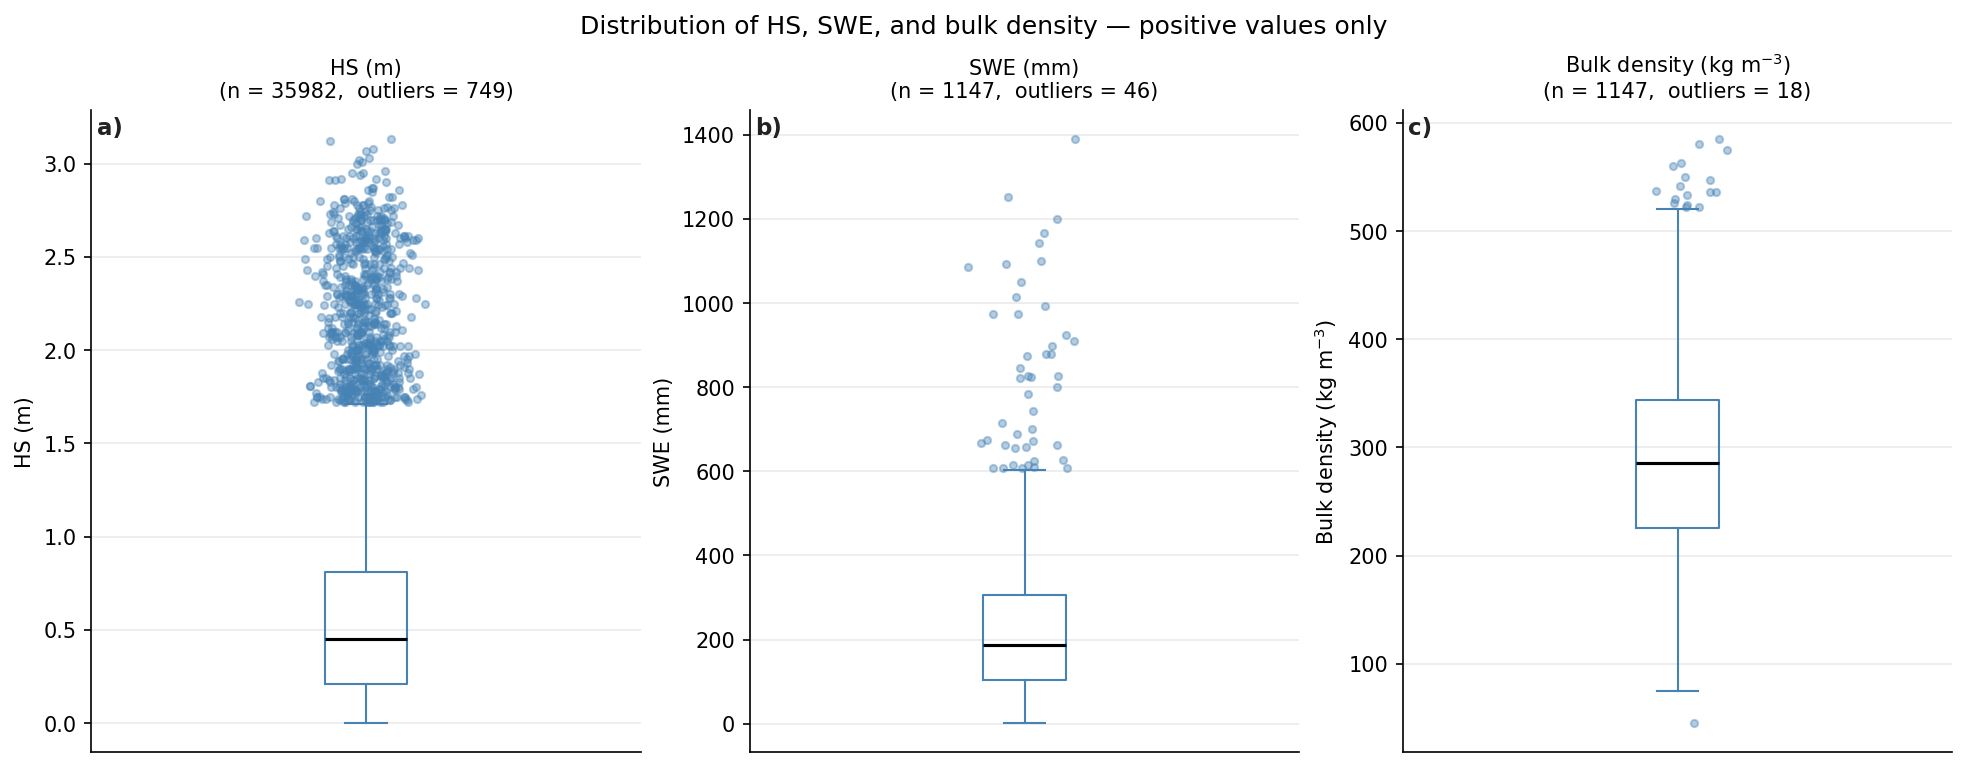

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[3]))  # mt_dsnow root
from plot_style import add_subplot_labels

cols   = ["HS", "SWE", "bulk_density_kg_m3"]
labels = ["HS (m)", "SWE (mm)", r"Bulk density (kg m$^{-3}$)"]

fig, axes = plt.subplots(1, 3, figsize=(13, 5), constrained_layout=True)

for ax, col, label in zip(axes, cols, labels):
    s = df_clean[col].dropna()
    s = s[s > 0]

    ax.boxplot(
        s.values, vert=True, showfliers=False,
        medianprops  = dict(color="black",    linewidth=1.5),
        boxprops     = dict(color="steelblue"),
        whiskerprops = dict(color="steelblue"),
        capprops     = dict(color="steelblue"),
    )

    # Jitter outlier points so density is visible
    q1, q3  = s.quantile([0.25, 0.75])
    iqr     = q3 - q1
    out     = s[(s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)]
    np.random.seed(0)
    ax.scatter(np.random.normal(1, 0.04, len(out)), out,
               color="steelblue", s=12, alpha=0.4, zorder=3)

    ax.set_title(f"{label}\n(n = {len(s)},  outliers = {len(out)})", fontsize=10)
    ax.set_xticks([])
    ax.set_ylabel(label)
    ax.grid(True, axis="y", alpha=0.25)

fig.suptitle("Distribution of HS, SWE, and bulk density — positive values only", fontsize=12)
add_subplot_labels(axes)
plt.show()

# Chek rho 0 and HNW

In [6]:
# calculate rho_0

rho0 = (ds["HNW"] / ds["HN"]).where(ds["HN"] > 0)

mean_rho0 = float(rho0.mean(skipna=True))



stations = ds["station"].values

rho0_by_station = [
    rho0.sel(station=st).values[~np.isnan(rho0.sel(station=st).values)]
    for st in stations
]

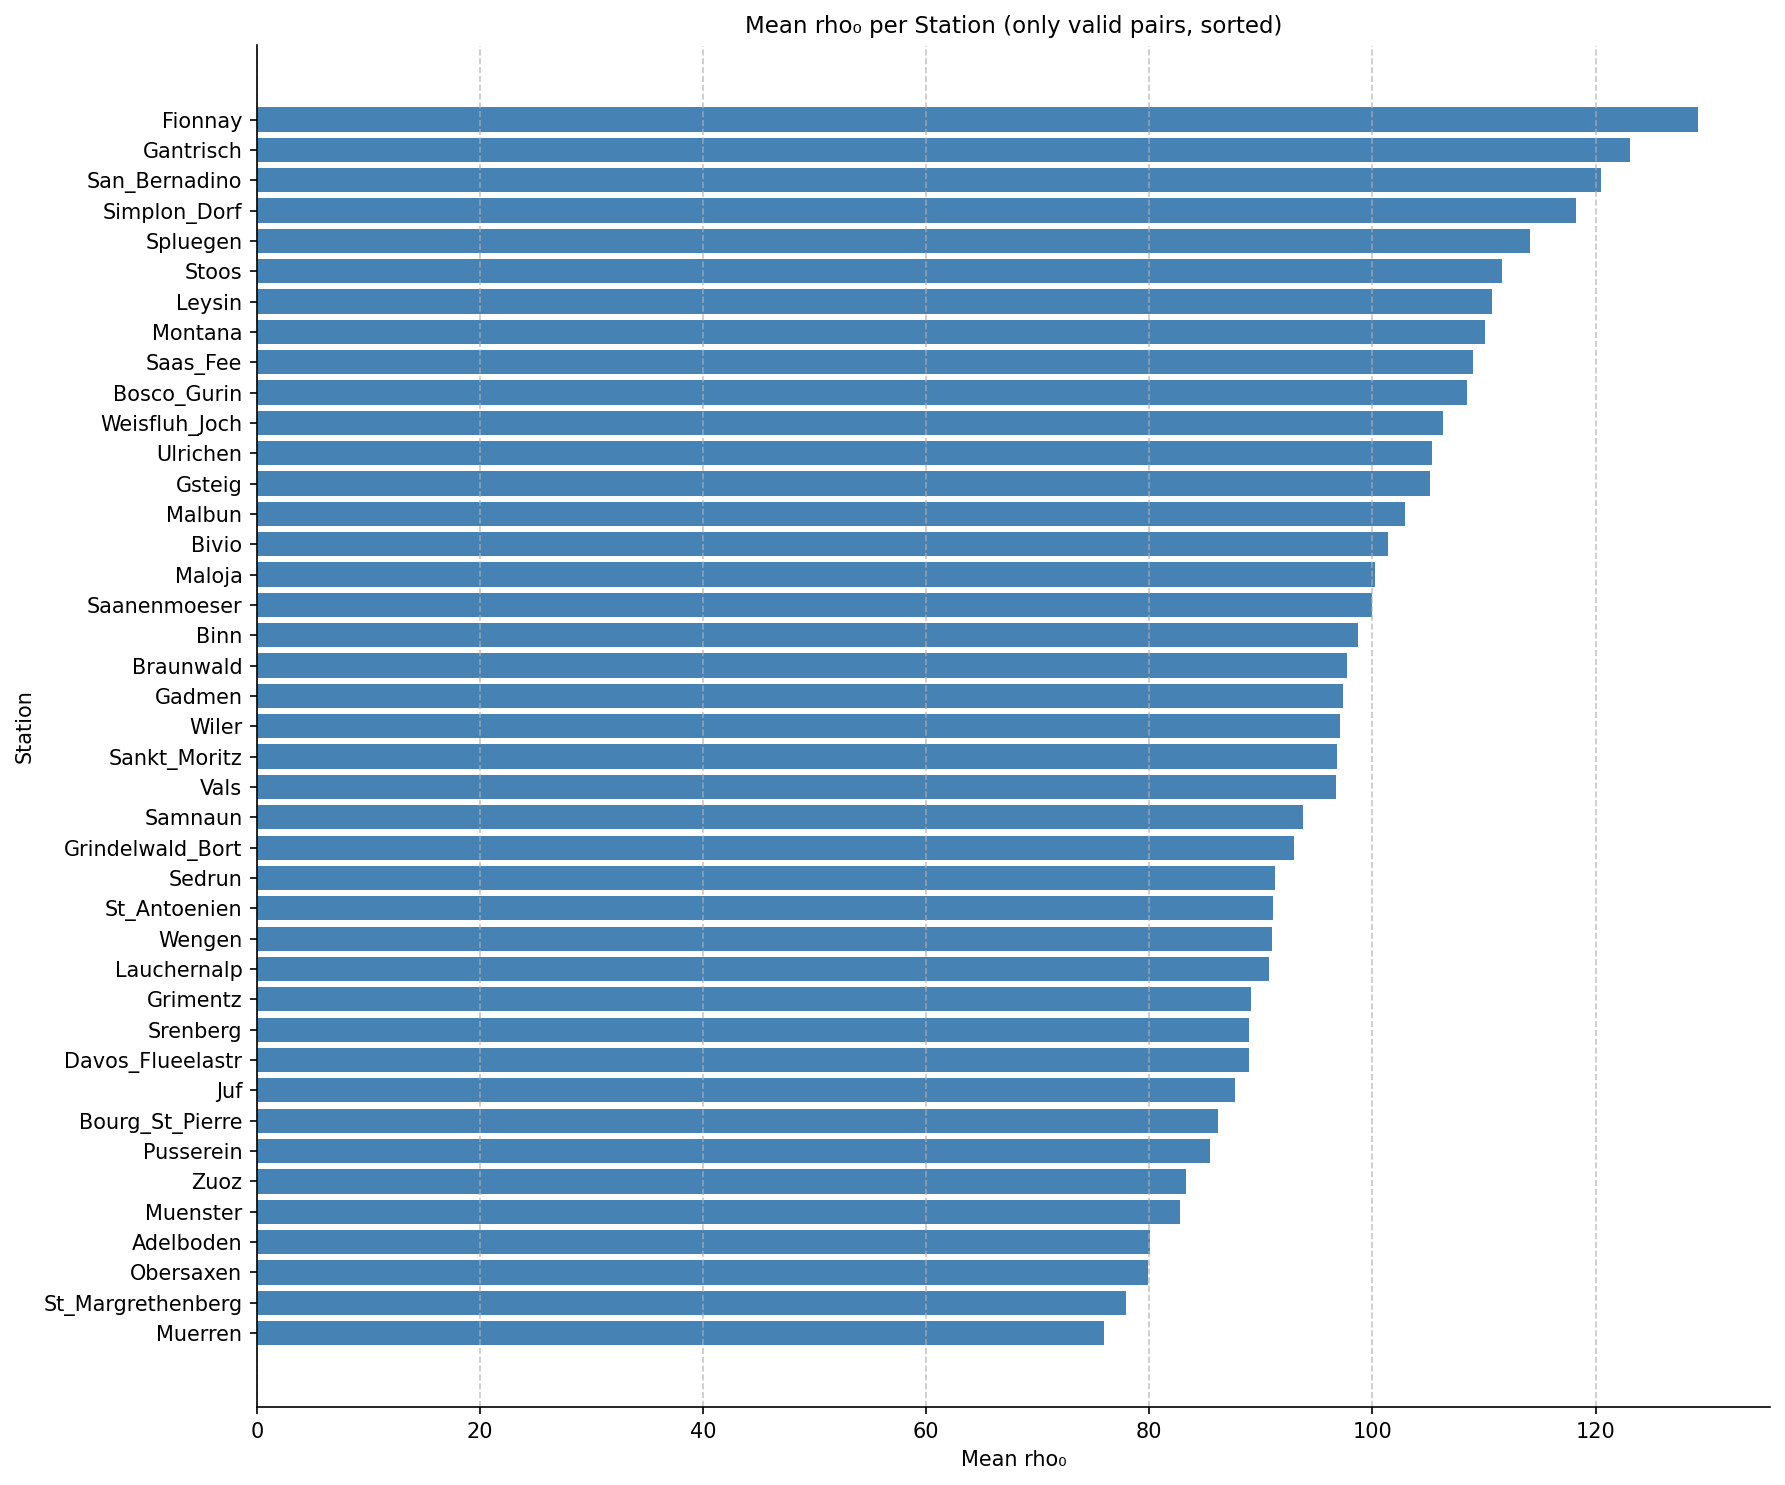

In [7]:
## Check the new snow swe by station 

# Compute rho0 only where both HNW and HN are valid
rho0 = ds.HNW / ds.HN
rho0 = rho0.where(ds.HNW.notnull() & ds.HN.notnull())

# Mean across time, skipping NaNs
mean_rho_0 = rho0.mean(dim="time", skipna=True)

# Sort stations by mean_rho_0
mean_rho_0_sorted = mean_rho_0.sortby(mean_rho_0)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(mean_rho_0_sorted.station.values, mean_rho_0_sorted.values, color="steelblue")

# Formatting
ax.set_xlabel("Mean rho₀")
ax.set_ylabel("Station")
ax.set_title("Mean rho₀ per Station (only valid pairs, sorted)")
ax.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

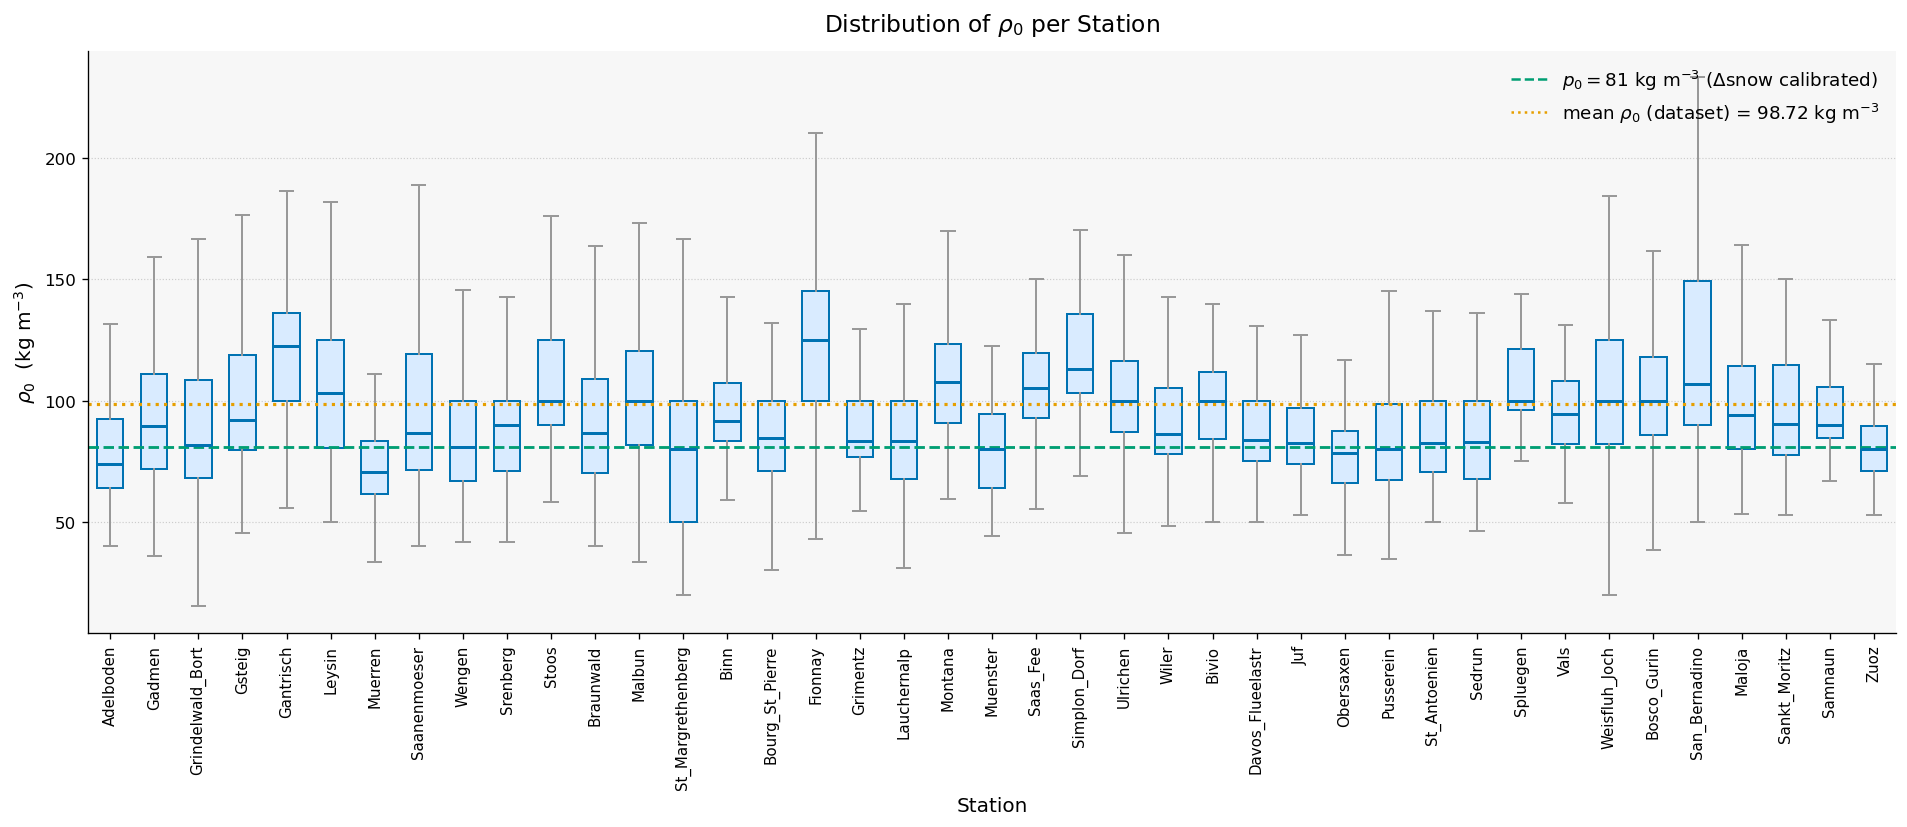

In [8]:
# --- Colorblind-safe palette (Okabe–Ito), distinct choices ---
CB_BLUE   = "#0072B2"  # blue
CB_ORANGE = "#E69F00"  # orange
CB_GREEN  = "#009E73"  # green
CB_GREY   = "#999999"  # grey

# --- Figure style ---
plt.style.use("default")
fig, ax = plt.subplots(figsize=(16, 7), dpi=120)

# Light background
ax.set_facecolor("#F7F7F7")
fig.patch.set_facecolor("#FFFFFF")

# Optional: modern look – hide top/right spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# --- Boxplot ---
bp = ax.boxplot(
    rho0_by_station,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
    medianprops=dict(color=CB_BLUE, linewidth=1.8),
    whiskerprops=dict(color=CB_GREY, linewidth=1.2),
    capprops=dict(color=CB_GREY, linewidth=1.2),
    boxprops=dict(
        facecolor="#D9EBFF",
        edgecolor=CB_BLUE,
        linewidth=1.2
    )
)

# --- X-axis labels ---
ax.set_xticks(np.arange(1, len(stations) + 1))
ax.set_xticklabels(stations, rotation=90, fontsize=9)
ax.tick_params(axis="y", labelsize=10)

# --- Labels & Title ---
ax.set_ylabel(r"$\rho_0$  (kg m$^{-3}$)", fontsize=12)
ax.set_xlabel("Station", fontsize=12)
ax.set_title(r"Distribution of $\rho_0$ per Station", fontsize=14, pad=12)

# --- Grid ---
ax.grid(axis="y", linestyle=":", linewidth=0.7, color="#CCCCCC")
ax.set_axisbelow(True)

# --- Reference lines ---
p0 = 81.0
ax.axhline(p0, linestyle="--", linewidth=1.7, color=CB_GREEN)

# Dataset-wide mean rho0 (explicitly recomputed from ds)
mean_rho0_dataset = float(((ds["HNW"] / ds["HN"]).where(ds["HN"] > 0)).mean(skipna=True))
ax.axhline(mean_rho0_dataset, linestyle=":", linewidth=1.9, color=CB_ORANGE)

# --- Legend ---
line_p0 = mlines.Line2D(
    [], [], linestyle="--", color=CB_GREEN,
    label=r"$p_0 = 81$ kg m$^{-3}$ (Δsnow calibrated)"
)
line_mean = mlines.Line2D(
    [], [], linestyle=":", color=CB_ORANGE,
    label=rf"mean $\rho_0$ (dataset) = {mean_rho0_dataset:.2f} kg m$^{{-3}}$"
)

ax.legend(handles=[line_p0, line_mean], loc="upper right", frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


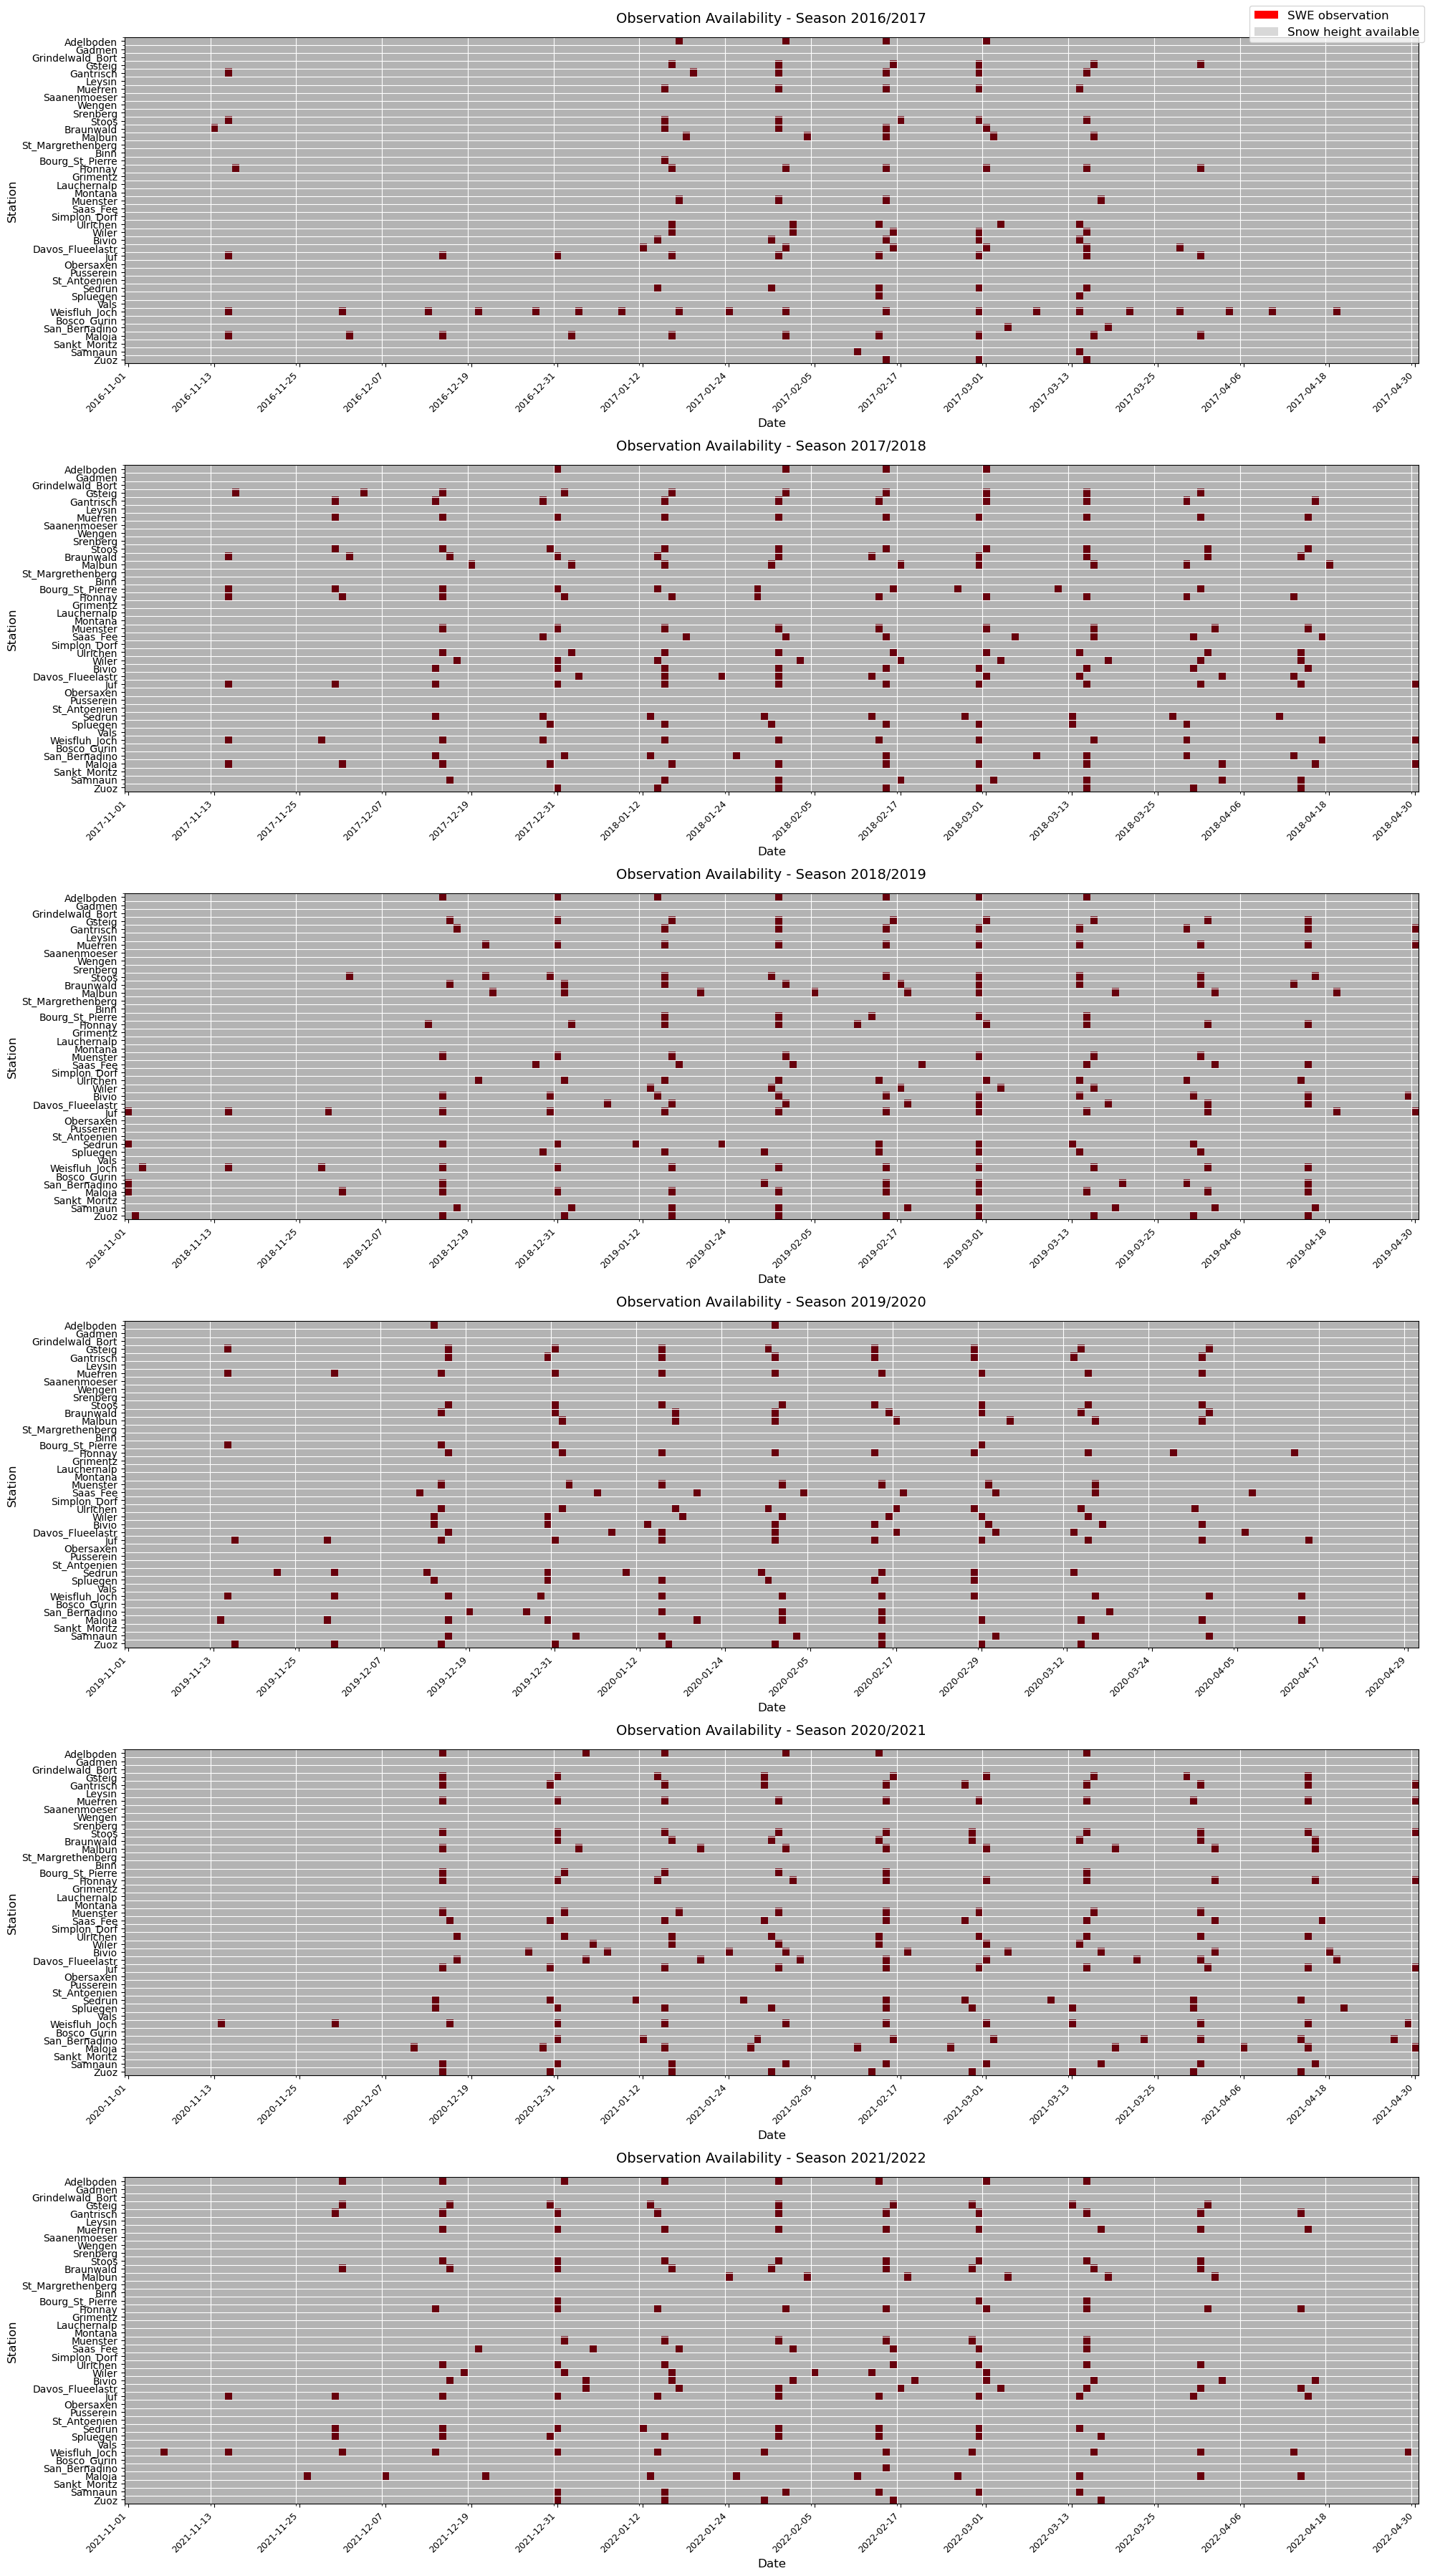

In [9]:
import pandas as pd
from matplotlib.patches import Patch
import numpy as np

# Create a calendar-like visualization showing when SWE and snow height observations are available
# One plot per season (Nov 1 - Apr 30)

# Convert time to pandas datetime for easier season extraction
time_df = pd.DataFrame({'time': pd.to_datetime(ds['time'].values)})
time_df['year'] = time_df['time'].dt.year
time_df['month'] = time_df['time'].dt.month

# Define seasons: Nov 1 to Apr 30
# Season year is based on the year when season starts (November)
def get_season(row):
    month = row['month']
    year = row['year']
    if month >= 11:  # Nov, Dec
        return f"{year}/{year+1}"
    elif month <= 4:  # Jan, Feb, Mar, Apr
        return f"{year-1}/{year}"
    else:
        return None  # Outside season

time_df['season'] = time_df.apply(get_season, axis=1)

# Filter to only include data within seasons
time_df = time_df[time_df['season'].notna()]

# Create availability masks - check for non-null values
swe_available = ds["SWE"].notnull().astype(int)
hs_available = ds["HS"].notnull().astype(int)

# Get unique seasons
seasons = time_df['season'].unique()

# Create subplots for each season with larger figure
n_seasons = len(seasons)
fig, axes = plt.subplots(n_seasons, 1, figsize=(20, 6*n_seasons))

if n_seasons == 1:
    axes = [axes]

for idx, season in enumerate(sorted(seasons)):
    ax = axes[idx]
    
    # Get time indices for this season
    season_mask = time_df['season'] == season
    season_times = time_df[season_mask]['time'].values
    season_indices = time_df[season_mask].index.values
    
    # Extract data for this season
    hs_season = hs_available.isel(time=season_indices)
    swe_season = swe_available.isel(time=season_indices)
    
    # Plot HS as light gray background shading
    im1 = ax.imshow(
        hs_season.T,
        aspect="auto",
        cmap="Greys",
        interpolation="nearest",
        vmin=0,
        vmax=1,
        alpha=0.3
    )
    
    # Plot SWE as red marks - mask where SWE is not available (0)
    swe_masked = np.ma.masked_where(swe_season.T == 0, swe_season.T)
    im2 = ax.imshow(
        swe_masked,
        aspect="auto",
        cmap="Reds",
        interpolation="none",
        vmin=0,
        vmax=1,
        alpha=1.0
    )
    
    # Set ticks and labels
    ax.set_yticks(np.arange(len(stations)))
    ax.set_yticklabels(stations, fontsize=10)
    
    # Format x-axis with dates
    n_times_season = len(season_times)
    step_season = max(n_times_season // 15, 1)
    ax.set_xticks(np.arange(0, n_times_season, step_season))
    ax.set_xticklabels(
        [str(t)[:10] for t in season_times[::step_season]],
        rotation=45,
        ha="right",
        fontsize=9
    )
    
    # Labels and title
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Station", fontsize=12)
    ax.set_title(f"Observation Availability - Season {season}", fontsize=14, pad=15)
    
    # Grid
    ax.set_xticks(np.arange(0, n_times_season, step_season) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(stations)) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)

# Add legend
legend_elements = [
    Patch(facecolor='red', alpha=1.0, label='SWE observation'),
    Patch(facecolor='gray', alpha=0.3, label='Snow height available')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()

#plt.savefig('calibration/calibration_data/raw_data/mag25/viz_analysis/swe_hs_availability_calendar.png', dpi=300)
plt.show()